# Notebook 1 — Phylogenetics, Orthology & Paralogy

## Objectives
- Understand **orthology** and **paralogy** from gene/species tree reconciliation
- Use **ETE3** to load, annotate, and visualize phylogenetic trees
- Query the **NCBI taxonomy** database programmatically
- Build a multiple sequence alignment with **MAFFT**
- Trim alignments: **trimAl** and a custom gap-filter function
- Compute basic **alignment statistics**

## Orthology and Paralogy

![Species/Gene tree](../figures/fig1_orthology.png "Species and Gene tree")

**Orthologs** arise from **speciation (S)** — they are the "same gene" in different species and typically retain the same function.

**Paralogs** arise from **gene duplication (D)** — they are related genes within a genome that may diverge in function (sub- or neo-functionalization).

Distinguishing orthologs from paralogs is fundamental in comparative genomics: orthologs are our best bet for transferring functional annotations across species, while paralogs tell us about gene family expansion and functional diversification.

---
## 1. Simple gene tree: Cytochrome c oxidase I (COX1)

COX1 is a mitochondrial gene widely used as a phylogenetic marker. The tree has sequences from three species — human, mouse, and fruit fly. We use [ETE3](http://etetoolkit.org/) for tree visualization inside the notebook.

In [1]:
from ete3 import PhyloTree, TreeStyle, faces

# Load tree — taxid is the part before the dot in each leaf name
t = PhyloTree(open("../data/cox1.nw").read(),
              sp_naming_function=lambda node: node.name.split('.')[0])

# Root at midpoint
t.set_outgroup(t.get_midpoint_outgroup())
print(t)


   /-7227.P00399
--|
  |   /-9606.P00395
   \-|
      \-10090.P00397


In [2]:
# Annotate with NCBI taxonomy (downloads DB on first run)
print("Annotating with NCBI taxonomy...")
t.annotate_ncbi_taxa()

print(t.get_ascii(attributes=['sci_name', 'name']))

Annotating with NCBI taxonomy...

           /-Drosophila melanogaster, 7227.P00399
-Bilateria, 
          |                  /-Homo sapiens, 9606.P00395
           \Euarchontoglires, 
                             \-Mus musculus, 10090.P00397


In [ ]:
# Render inline — default style
t.render("%%inline")
# t.show()

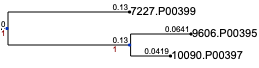

In [5]:
# Customize the tree style
ts = TreeStyle()
ts.show_leaf_name = False
ts.show_scale = False
ts.show_branch_length = True
ts.show_branch_support = True

t.render("%%inline", tree_style=ts)

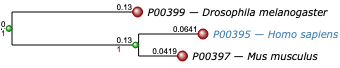

In [6]:
# Custom layout: control how each node looks
def cox1_layout(node):
    if node.is_leaf():
        node.img_style['size'] = 10
        node.img_style["shape"] = "sphere"
        node.img_style["fgcolor"] = "darkred"
        name = faces.TextFace(
            f"{node.name.split('.')[1]} — {node.sci_name}", fstyle="italic")
        name.margin_left = 5
        if node.taxid == 9606:
            name.fgcolor = "steelblue"
        faces.add_face_to_node(name, node, column=0)
    else:
        node.img_style['size'] = 6
        node.img_style["shape"] = "sphere"
        node.img_style["fgcolor"] = "green"

t.render("%%inline", tree_style=ts, layout=cox1_layout)

### Evolutionary events

ETE can infer whether internal nodes represent **speciation** or **duplication** events by comparing species overlap between descendant clades.

With only one gene per species, COX1 should show only speciation events.

In [7]:
events = t.get_descendant_evol_events()

for node in t.traverse():
    if 'evoltype' in node.features:
        print(node.name, node.evoltype)

print(t.get_ascii(attributes=['evoltype', 'name']))

 S
 S

   /-7227.P00399
-S, 
  |   /-9606.P00395
   \S, 
      \-10090.P00397


---
## 2. A gene family with duplications: SLC23A (vitamin C transporters)

The SLC23A family has four paralogs in mouse, three in human, and one in *Drosophila*. We need to understand **duplication nodes** clearly before scaling up.

In [8]:
# Load the SLC23A tree
t = PhyloTree(open("../data/slc23a.nw").read(),
              sp_naming_function=lambda node: node.name.split('.')[0])

# Midpoint rooting
t.set_outgroup(t.get_midpoint_outgroup())

# Annotate
t.annotate_ncbi_taxa()
print(t.get_ascii(attributes=["name", "sci_name"]))


                             /-10090.Q60850, Mus musculus
           /, Euarchontoglires
          |                  \-9606.Q6PIS1, Homo sapiens
          |
          |                                               /-10090.Q9EPR4, Mus musculus
-, Bilateria                            /, Euarchontoglires
          |                            |                  \-9606.Q9UGH3, Homo sapiens
          |           /, Euarchontoglires
          |          |                 |                  /-9606.Q9UHI7, Homo sapiens
          |          |                  \, Euarchontoglires
           \, Bilateria                                   \-10090.Q9Z2J0, Mus musculus
                     |
                     |           /-7227.Q9VH02, Drosophila melanogaster
                      \, Bilateria
                                 \-10090.A0A0J9YUX7, Mus musculus


Now root the tree using the *Drosophila melanogaster* sequence as outgroup — this is biologically more meaningful than midpoint rooting.

In [9]:
t.set_outgroup("7227.Q9VH02")
print(t.get_ascii(attributes=["name", "sci_name"]))


           /-7227.Q9VH02, Drosophila melanogaster
          |
          |           /-10090.A0A0J9YUX7, Mus musculus
-, Bilateria         |
          |          |                                               /-10090.Q9EPR4, Mus musculus
          |          |                             /, Euarchontoglires
           \, Bilateria                           |                  \-9606.Q9UGH3, Homo sapiens
                     |           /, Euarchontoglires
                     |          |                 |                  /-9606.Q9UHI7, Homo sapiens
                     |          |                  \, Euarchontoglires
                      \, Bilateria                                   \-10090.Q9Z2J0, Mus musculus
                                |
                                |                  /-10090.Q60850, Mus musculus
                                 \, Euarchontoglires
                                                   \-9606.Q6PIS1, Homo sapiens


In [10]:
# Re-annotate after re-rooting and infer duplication/speciation events
t.annotate_ncbi_taxa()
events = t.get_descendant_evol_events()

n_dup = sum(1 for e in events if e.etype == "D")
n_spec = sum(1 for e in events if e.etype == "S")
print(f"Duplication events: {n_dup}")
print(f"Speciation events: {n_spec}")

# Load gene names
seqid2gene = {}
for line in open("../data/slc23a.seqid2gname.tab"):
    parts = line.strip().split("\t")
    if len(parts) >= 2:
        seqid2gene[parts[0]] = parts[1]

print("\nGene names:")
for leaf in t.get_leaves():
    gname = seqid2gene.get(leaf.name, "?")
    print(f"  {leaf.name:<25s} {leaf.sci_name:<25s} {gname}")

Duplication events: 3
Speciation events: 4

Gene names:
  7227.Q9VH02               Drosophila melanogaster   Dmel\CG6293
  10090.A0A0J9YUX7          Mus musculus              Slc23a4
  10090.Q9EPR4              Mus musculus              Slc23a2
  9606.Q9UGH3               Homo sapiens              SLC23A2
  9606.Q9UHI7               Homo sapiens              SLC23A1
  10090.Q9Z2J0              Mus musculus              Slc23a1
  10090.Q60850              Mus musculus              Slc23a3
  9606.Q6PIS1               Homo sapiens              SLC23A3


### ✏️ Exercise 1

**Task:** Render the SLC23A tree inline with:
1. **Duplication** nodes marked with red squares
2. Each species in a different color
3. Leaf labels showing both the gene name and the species

Hint: write a `layout` function that checks `node.evoltype` for internal nodes and uses `faces.TextFace` for leaves. Use `t.render("%%inline", tree_style=ts, layout=your_layout)`.

In [11]:
# YOUR CODE


---
## 3. The NCBI Taxonomy database

ETE provides a local interface to the [NCBI Taxonomy](https://www.ncbi.nlm.nih.gov/taxonomy) — a single hierarchical classification of all organisms.

In [12]:
from ete3 import NCBITaxa

ncbi = NCBITaxa()

# Translate taxids to species names
taxid2name = ncbi.get_taxid_translator([9606, 10090, 7227])
print(taxid2name)

{7227: 'Drosophila melanogaster', 9606: 'Homo sapiens', 10090: 'Mus musculus'}


In [13]:
# Build a taxonomy tree for these species
tree = ncbi.get_topology([9606, 10090, 7227])
print(tree.get_ascii(attributes=["sci_name", "rank"]))


                                            /-Mus musculus, species
                /Euarchontoglires, superorder
-Bilateria, clade                           \-Homo sapiens, species
               |
                \-Drosophila melanogaster, species


### ✏️ Exercise 2

Use `ncbi.get_lineage()` and `ncbi.get_taxid_translator()` to print the full taxonomic lineage for taxid 9739 (bottlenose dolphin). What order does it belong to?

Then build a taxonomy tree (`ncbi.get_topology()`) for human, mouse, dog (9615), cow (9913), dolphin (9739), and horseshoe bat (59479). Render it inline.

In [ ]:
# YOUR CODE HERE


---
## 4. The SLC26 dataset

We have 297 canonical protein sequences from 30 mammalian species, selected by having both Pfam domains PF01740 (Sulphate_transp) and PF00916 (STAS). The FASTA was prepared from UniProt reference proteomes (see `scripts/uniprot_phylo.py`). Headers use the format `>taxid.accession`.

In [ ]:
import os, subprocess
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

DATA = os.path.join("..", "data")
FIGS = os.path.join("..", "figures")
FASTA = os.path.join(DATA, "selection2_clustalo.fa")

# Look at the data
n_seqs = sum(1 for line in open(FASTA) if line.startswith(">"))
taxids = set()
for line in open(FASTA):
    if line.startswith(">"):
        taxids.add(line.strip()[1:].split(".")[0])

print(f"Sequences: {n_seqs}")
print(f"Species (unique taxids): {len(taxids)}")

Sequences: 297
Species (unique taxids): 30


### ✏️ Exercise 3

Write code to compute the **sequence length distribution** (ungapped lengths) and plot a histogram. Are all sequences similar in length, or are there outliers?

Hint: use `ete3.parser.fasta.read_fasta`, `Bio.SeqIO`, or your function to parse the FASTA.

In [ ]:
# YOUR CODE HERE


---
## 5. Multiple sequence alignment with MAFFT

These SLC26 proteins share only ~20–40% identity across subfamilies, making alignment non-trivial. We use [MAFFT](https://mafft.cbrc.jp/alignment/software/) (`--auto` selects the best strategy based on dataset size).

Other popular aligners: [ClustalOmega](http://www.clustal.org/omega/), [MUSCLE](https://drive5.com/muscle5/).

In [19]:
ALN = os.path.join(DATA, "slc26.mafft.fa")

if not os.path.exists(ALN):
    print("Running MAFFT (--auto)... this should be fast (a few seconds) for 297 sequences")
    with open(ALN, "w") as f:
        subprocess.run(["mafft", "--auto", "--thread", "-1", FASTA],
                       stdout=f, stderr=subprocess.PIPE, check=True)
    print("Done.")
else:
    print(f"Cached: {ALN}")

from Bio import AlignIO
aln = AlignIO.read(ALN, "fasta")
print(f"Alignment: {len(aln)} sequences × {aln.get_alignment_length()} columns")

Cached: ../data/slc26.mafft.fa
Alignment: 297 sequences × 6435 columns


### 5.1 Alignment statistics

Alignment length: 6435 columns
Columns with 0 gaps: 57
Columns with >50% gaps: 5716
Columns with >90% gaps: 5460
Mean gap fraction: 0.878


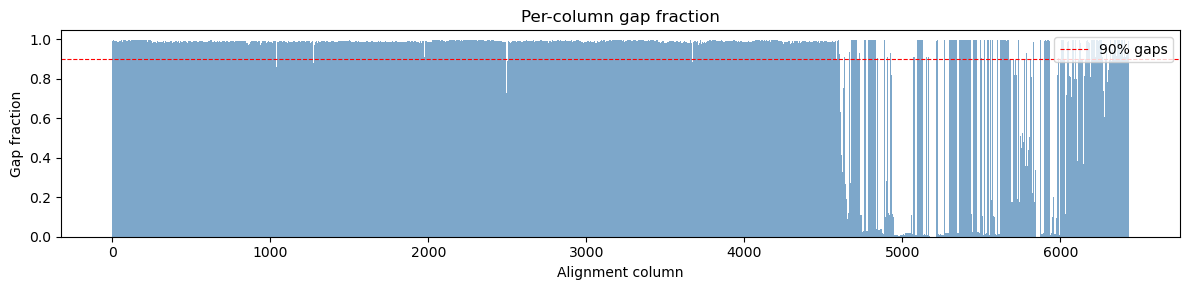

In [20]:
# Per-column gap fraction
ncols = aln.get_alignment_length()
nseqs = len(aln)

gap_fracs = np.zeros(ncols)
for col in range(ncols):
    column = aln[:, col]
    gap_fracs[col] = column.count("-") / nseqs

print(f"Alignment length: {ncols} columns")
print(f"Columns with 0 gaps: {np.sum(gap_fracs == 0)}")
print(f"Columns with >50% gaps: {np.sum(gap_fracs > 0.5)}")
print(f"Columns with >90% gaps: {np.sum(gap_fracs > 0.9)}")
print(f"Mean gap fraction: {gap_fracs.mean():.3f}")

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(ncols), gap_fracs, width=1, color="steelblue", alpha=0.7)
ax.set_xlabel("Alignment column")
ax.set_ylabel("Gap fraction")
ax.set_title("Per-column gap fraction")
ax.axhline(0.9, color="red", ls="--", lw=0.8, label="90% gaps")
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Alignment trimming

Columns dominated by gaps add noise to tree inference. We remove them before building the tree.

### 6.1 trimAl

[trimAl](http://trimal.cgenomics.org/) is a widely used tool. The flag `-gt 0.1` keeps only columns where at least 10% of sequences have a non-gap character (i.e., removes columns with >90% gaps).

In [ ]:
TRIM = os.path.join(DATA, "slc26.mafft.gt01.fa")

if not os.path.exists(TRIM):
    subprocess.run(["trimal", "-in", ALN, "-out", TRIM, "-gt", "0.1", "-fasta"],
                   check=True, capture_output=True)

aln_trim = AlignIO.read(TRIM, "fasta")
print(f"Before trim: {aln.get_alignment_length()} columns")
print(f"After trim:  {aln_trim.get_alignment_length()} columns  "
      f"({aln.get_alignment_length() - aln_trim.get_alignment_length()} removed)")

### ✏️ Exercise 4a

Try different trimAl settings: `-gt 0.3` (stricter) and `-gappyout` (automatic heuristic). How many columns does each retain? Which would you use for tree building and why?

In [ ]:
# YOUR CODE HERE


### ✏️ Exercise 4b — Write your own gap-trimming function

Write a function `trim_by_gaps(alignment, threshold)` that takes a BioPython `MultipleSeqAlignment` and a gap threshold (0 to 1), and returns a new alignment keeping only columns where the fraction of non-gap characters is ≥ threshold.

This is essentially what `trimal -gt` does.

In [ ]:
from Bio.Align import MultipleSeqAlignment
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

def trim_by_gaps(alignment, threshold=0.1):
    """Keep columns where fraction of non-gap chars >= threshold."""
    # YOUR CODE HERE
    pass

# Test it:
# my_trim = trim_by_gaps(aln, threshold=0.1)
# print(f"Custom trim: {my_trim.get_alignment_length()} columns")
# print(f"trimAl:      {aln_trim.get_alignment_length()} columns")

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
def trim_by_gaps(alignment, threshold=0.1):
    ncols = alignment.get_alignment_length()
    nseqs = len(alignment)
    keep = []
    for col in range(ncols):
        column = alignment[:, col]
        nongap_frac = 1 - column.count("-") / nseqs
        if nongap_frac >= threshold:
            keep.append(col)
    # Build new alignment from kept columns
    new_records = []
    for rec in alignment:
        new_seq = "".join(str(rec.seq)[c] for c in keep)
        new_records.append(SeqRecord(Seq(new_seq), id=rec.id, description=""))
    return MultipleSeqAlignment(new_records)
```
</details>

---
## Summary

- **Orthologs** (speciation) vs **paralogs** (duplication) — the key distinction in comparative genomics
- **ETE3**: load trees, annotate with NCBI taxonomy, infer evolutionary events, render inline
- **NCBI Taxonomy**: query taxids, build taxonomy trees
- **MAFFT**: fast multiple sequence alignment (alternatives: ClustalOmega, MUSCLE)
- **Trimming**: remove gappy columns before tree building (trimAl or custom function)

We have our SLC26 alignment trimmed and ready. In **Notebook 2** we build the tree, explore it interactively with **ETE4**, identify the prestin subfamily, and compare phylogenetic methods.